# Notebook 12 compares the optimal operation of the
integrated PV+BESS+EV system under three representative
charging-demand conditions:

- Low-demand day
- Medium-demand day
- High-demand day

The objective is to evaluate how charging demand affects:

• energy cost
• battery usage
• PV utilization
• grid dependence

while using the same PV and BESS sizes.

In [9]:
# ==========================================================
# Notebook 12: Multi-scenario comparison
#
# Goal:
# Run the integrated PV + BESS + flexible EV charging LP
# for different representative EV demand days.
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.optimize import linprog

In [10]:
# ==========================================================
# Load yearly datasets
# ==========================================================

ev = pd.read_csv("../data/raw/ev_sessions.csv")

load_mat = loadmat("../data/raw/load_yearly.mat")
pv_mat = loadmat("../data/raw/PV_production_yearly.mat")
price_mat = loadmat("../data/raw/prices_yearly.mat")

load_year = load_mat["load_all_year"].flatten()
pv_factor = pv_mat["zeta_PV"].flatten()
price_year = price_mat["prices_all_year"].flatten()

print("EV sessions:", len(ev))
print("Load shape :", load_year.shape)
print("PV shape   :", pv_factor.shape)
print("Price shape:", price_year.shape)

EV sessions: 8530
Load shape : (8760,)
PV shape   : (8760,)
Price shape: (8760,)


In [11]:
# ==========================================================
# Load datasets
# ==========================================================

ev = pd.read_csv("../data/raw/ev_sessions.csv")

load_mat = loadmat("../data/raw/load_yearly.mat")
pv_mat = loadmat("../data/raw/PV_production_yearly.mat")
price_mat = loadmat("../data/raw/prices_yearly.mat")

load_year = load_mat["load_all_year"].flatten()
pv_factor = pv_mat["zeta_PV"].flatten()
price_year = price_mat["prices_all_year"].flatten()

print("Data loaded successfully")
print("EV sessions:", len(ev))
print("Load shape:", load_year.shape)
print("PV shape:", pv_factor.shape)
print("Price shape:", price_year.shape)

Data loaded successfully
EV sessions: 8530
Load shape: (8760,)
PV shape: (8760,)
Price shape: (8760,)


Represented Data

In [12]:
# ==========================================================
# Representative EV demand scenarios
#
# These days were selected earlier from the yearly EV dataset:
#
# Low-demand day:
#     smallest daily EV energy
#
# Medium-demand day:
#     closest to median daily EV energy
#
# High-demand day:
#     largest daily EV energy
# ==========================================================

scenario_days = {
    "Low": 106,
    "Medium": 20,
    "High": 95
}

scenario_days

{'Low': 106, 'Medium': 20, 'High': 95}

System Paramters

In [13]:
# ==========================================================
# Fixed system parameters
#
# Same PV and BESS sizes are used for all scenarios
# so that the comparison is fair.
# ==========================================================

S_PV = 300          # PV size [kWp]

E_BESS = 200        # Battery capacity [kWh]
P_BESS_max = 50     # Battery max charge/discharge power [kW]

eta_ch = 0.95
eta_dis = 0.95

SOC_min = 0.10 * E_BESS
SOC_max = 0.90 * E_BESS
SOC_initial = 0.50 * E_BESS

P_EV_max = 7.0      # Charger power per EV [kW]

N = 24
dt = 1.0

print("PV size [kWp]:", S_PV)
print("BESS capacity [kWh]:", E_BESS)
print("EV charger power [kW]:", P_EV_max)

PV size [kWp]: 300
BESS capacity [kWh]: 200
EV charger power [kW]: 7.0


In [14]:
# ==========================================================
# Function: solve integrated LP for one representative day
# ==========================================================
#
# This function contains the same optimization model from
# Notebook 11, but wrapped into a function so we can run it
# for Low / Medium / High scenarios automatically.
#
# Inputs:
#   day_number
#
# Outputs:
#   dictionary containing:
#   - optimal cost
#   - EV energy
#   - grid import/export
#   - battery throughput
#   - PV utilization indicators
# ==========================================================

def solve_integrated_lp(day_number):

    # ------------------------------------------------------
    # Extract one-day data
    # ------------------------------------------------------

    load_day = load_year[
        (day_number - 1) * 24 : day_number * 24
    ]

    pv_day = S_PV * pv_factor[
        (day_number - 1) * 24 : day_number * 24
    ]

    price_day = price_year[
        (day_number - 1) * 24 : day_number * 24
    ]

    ev_day = ev[
        ev["day"] == day_number
    ].copy()

    # Remove zero-energy sessions
    ev_opt = ev_day[
        ev_day["energy_kwh"] > 0
    ].copy()

    ev_opt = ev_opt.reset_index(drop=True)

    n_ev = len(ev_opt)

    # ------------------------------------------------------
    # Decision variable indexing
    # ------------------------------------------------------

    idx_ev_start = 0
    idx_bess_ch_start = idx_ev_start + n_ev * N
    idx_bess_dch_start = idx_bess_ch_start + N
    idx_soc_start = idx_bess_dch_start + N
    idx_grid_import_start = idx_soc_start + (N + 1)
    idx_grid_export_start = idx_grid_import_start + N

    n_vars = idx_grid_export_start + N

    # ------------------------------------------------------
    # Objective function
    # ------------------------------------------------------

    c = np.zeros(n_vars)

    for h in range(N):
        c[idx_grid_import_start + h] = price_day[h]

    # ------------------------------------------------------
    # Equality constraints
    # ------------------------------------------------------

    A_eq = []
    b_eq = []

    # Power balance
    for h in range(N):

        row = np.zeros(n_vars)

        # EV charging demand
        for i in range(n_ev):
            row[idx_ev_start + i * N + h] = 1.0

        # BESS charge/discharge
        row[idx_bess_ch_start + h] = 1.0
        row[idx_bess_dch_start + h] = -1.0

        # Grid import/export
        row[idx_grid_import_start + h] = -1.0
        row[idx_grid_export_start + h] = 1.0

        A_eq.append(row)
        b_eq.append(pv_day[h] - load_day[h])

    # EV energy requirements
    for i in range(n_ev):

        row = np.zeros(n_vars)

        for h in range(N):
            row[idx_ev_start + i * N + h] = dt

        A_eq.append(row)
        b_eq.append(ev_opt.loc[i, "energy_kwh"])

    # BESS SOC dynamics
    for h in range(N):

        row = np.zeros(n_vars)

        row[idx_soc_start + h + 1] = 1.0
        row[idx_soc_start + h] = -1.0

        row[idx_bess_ch_start + h] = -eta_ch
        row[idx_bess_dch_start + h] = 1.0 / eta_dis

        A_eq.append(row)
        b_eq.append(0.0)

    # Initial SOC
    row = np.zeros(n_vars)
    row[idx_soc_start] = 1.0

    A_eq.append(row)
    b_eq.append(SOC_initial)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # ------------------------------------------------------
    # Bounds
    # ------------------------------------------------------

    bounds = []

    # EV charging bounds
    for i in range(n_ev):

        connection_minute = ev_opt.loc[i, "connection_minute"]
        disconnection_minute = ev_opt.loc[i, "disconnection_minute"]

        for h in range(N):

            hour_start = h * 60
            hour_end = (h + 1) * 60

            overlap_min = max(
                0,
                min(disconnection_minute, hour_end)
                - max(connection_minute, hour_start)
            )

            if overlap_min > 0:
                bounds.append((0, P_EV_max))
            else:
                bounds.append((0, 0))

    # BESS charge bounds
    for h in range(N):
        bounds.append((0, P_BESS_max))

    # BESS discharge bounds
    for h in range(N):
        bounds.append((0, P_BESS_max))

    # SOC bounds
    for h in range(N + 1):
        bounds.append((SOC_min, SOC_max))

    # Grid import bounds
    for h in range(N):
        bounds.append((0, None))

    # Grid export bounds
    for h in range(N):
        bounds.append((0, None))

    # ------------------------------------------------------
    # Solve LP
    # ------------------------------------------------------

    result = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        return {
            "day": day_number,
            "success": False,
            "message": result.message
        }

    # ------------------------------------------------------
    # Extract solution
    # ------------------------------------------------------

    x_opt = result.x

    P_EV_opt = x_opt[
        idx_ev_start : idx_bess_ch_start
    ].reshape(n_ev, N)

    ev_profile = P_EV_opt.sum(axis=0)

    P_ch = x_opt[
        idx_bess_ch_start : idx_bess_dch_start
    ]

    P_dch = x_opt[
        idx_bess_dch_start : idx_soc_start
    ]

    SOC = x_opt[
        idx_soc_start : idx_grid_import_start
    ]

    P_grid_import = x_opt[
        idx_grid_import_start : idx_grid_export_start
    ]

    P_grid_export = x_opt[
        idx_grid_export_start :
    ]

    # ------------------------------------------------------
    # KPIs
    # ------------------------------------------------------

    total_load = load_day.sum()
    total_pv = pv_day.sum()
    total_ev = ev_profile.sum()

    total_grid_import = P_grid_import.sum()
    total_grid_export = P_grid_export.sum()

    battery_throughput = P_ch.sum() + P_dch.sum()

    local_consumption = total_pv - total_grid_export

    pv_utilization = 100 * local_consumption / total_pv

    return {
        "day": day_number,
        "success": True,
        "cost_EUR": result.fun,
        "n_ev": n_ev,
        "EV_energy_kWh": total_ev,
        "load_energy_kWh": total_load,
        "PV_energy_kWh": total_pv,
        "grid_import_kWh": total_grid_import,
        "grid_export_kWh": total_grid_export,
        "battery_throughput_kWh": battery_throughput,
        "PV_utilization_percent": pv_utilization,
        "peak_EV_power_kW": ev_profile.max(),
        "peak_grid_import_kW": P_grid_import.max(),
    }

In [15]:
# ==========================================================
# Run all representative scenarios
# ==========================================================

scenario_results = []

for scenario_name, day_number in scenario_days.items():

    result_dict = solve_integrated_lp(day_number)

    result_dict["scenario"] = scenario_name

    scenario_results.append(result_dict)

scenario_results_df = pd.DataFrame(scenario_results)

scenario_results_df

,day,success,cost_EUR,n_ev,EV_energy_kWh,load_energy_kWh,PV_energy_kWh,grid_import_kWh,grid_export_kWh,battery_throughput_kWh,PV_utilization_percent,peak_EV_power_kW,peak_grid_import_kW,scenario
0,106,True,15.743027,5,37.0,1420.089812,1579.410,217.466200,399.365335,396.421053,74.714271,16.000000,43.498557,Low
1,20,True,111.822223,25,303.0,1431.669124,180.330,1496.644949,0.000000,433.198280,100.000000,132.000000,249.617557,Medium
2,95,True,16.831302,34,509.0,1432.217753,1674.636,244.893887,37.891081,396.421053,97.737354,120.063808,50.097780,High


Low day:
Low EV demand, high PV production.
Cost is low, but there is still grid export because PV exceeds local demand.

Medium day:
PV production is very low.
EV demand is moderate.
Grid import becomes very high and cost becomes much larger.

High day:
High EV demand, but also high PV production.
The system performs well because EV charging and PV availability align.

Scenario Cost Comparison

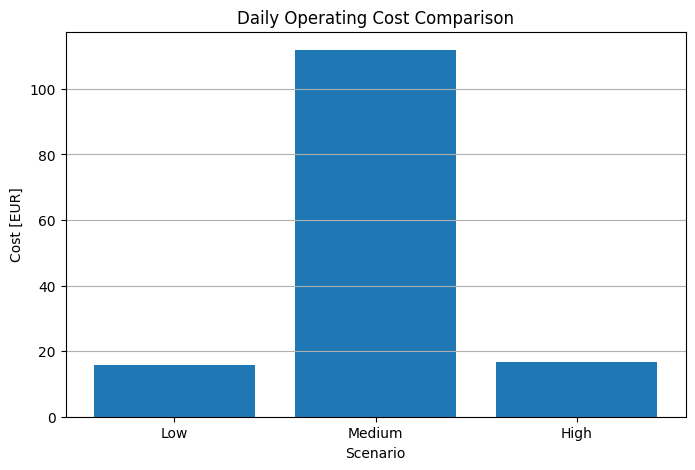

In [16]:
# ==========================================================
# Compare total operating cost
#
# Lower cost means:
# - less expensive grid imports
# - better use of PV
# - better use of battery flexibility
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    scenario_results_df["scenario"],
    scenario_results_df["cost_EUR"]
)

plt.ylabel("Cost [EUR]")
plt.xlabel("Scenario")

plt.title(
    "Daily Operating Cost Comparison"
)

plt.grid(axis="y")

plt.show()

Grid Import Comparison

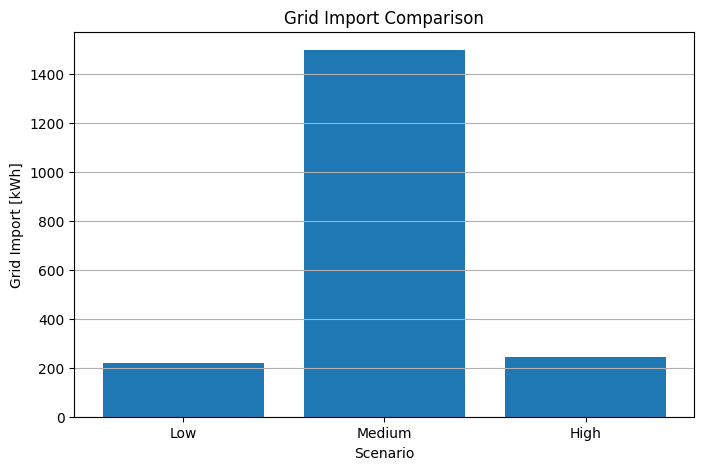

In [17]:
# ==========================================================
# Compare total grid imports
#
# Grid import is one of the most important KPIs.
#
# Lower import generally means:
# - better PV utilization
# - better battery usage
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    scenario_results_df["scenario"],
    scenario_results_df["grid_import_kWh"]
)

plt.ylabel("Grid Import [kWh]")
plt.xlabel("Scenario")

plt.title(
    "Grid Import Comparison"
)

plt.grid(axis="y")

plt.show()

PV utlization comparison

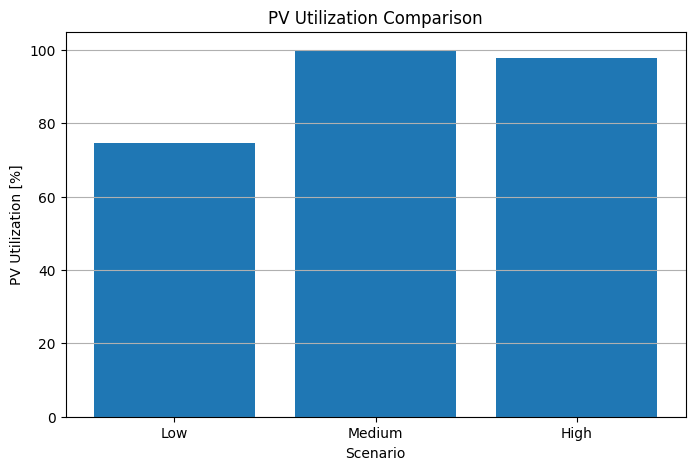

In [19]:
# ==========================================================
# Compare PV utilization
#
# PV utilization tells us how much locally produced
# PV energy is actually consumed.
#
# Higher is better.
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    scenario_results_df["scenario"],
    scenario_results_df["PV_utilization_percent"]
)

plt.ylabel("PV Utilization [%]")
plt.xlabel("Scenario")

plt.title(
    "PV Utilization Comparison"
)

plt.grid(axis="y")

plt.show()

Battery Usage Comparison

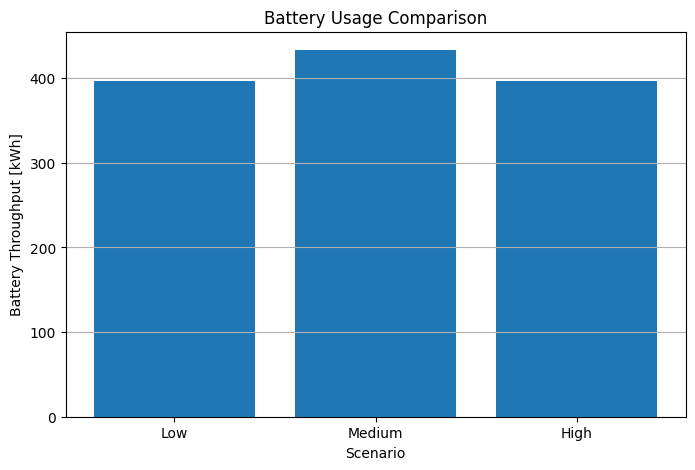

In [18]:
# ==========================================================
# Compare battery throughput
#
# Throughput =
# charge energy + discharge energy
#
# Indicates how actively the battery is used.
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    scenario_results_df["scenario"],
    scenario_results_df["battery_throughput_kWh"]
)

plt.ylabel("Battery Throughput [kWh]")
plt.xlabel("Scenario")

plt.title(
    "Battery Usage Comparison"
)

plt.grid(axis="y")

plt.show()

In [20]:
# ==========================================================
# Save scenario comparison table
# ==========================================================

scenario_results_df.to_csv(
    "../results/tables/scenario_comparison.csv",
    index=False
)

print("Saved scenario comparison table.")

Saved scenario comparison table.
